In [29]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['NanumGothic']


In [30]:
import matplotlib.pyplot as plt

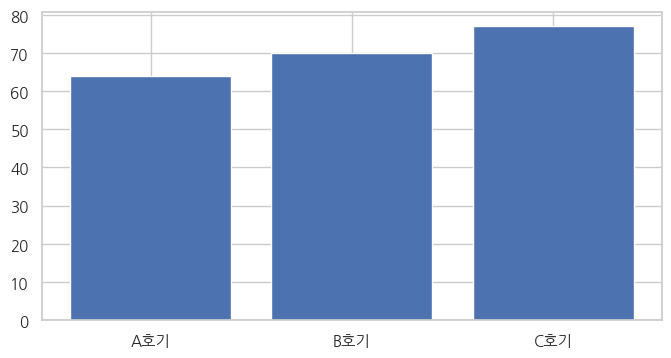

In [33]:
# 간단한 막대그래프
plt.figure(figsize=(8, 4))
plt.bar(['A호기', 'B호기', 'C호기'], [64, 70, 77])
plt.show()

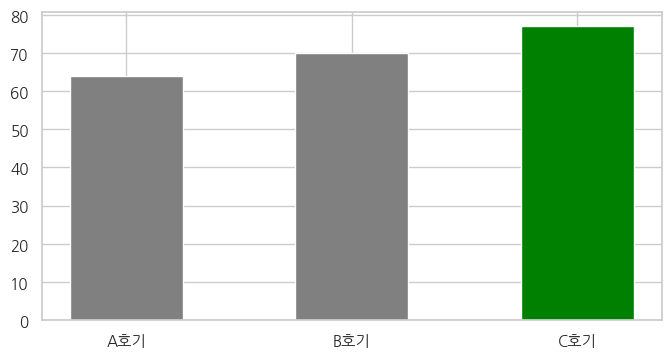

In [41]:
# 색상과 너비를 적용한 막대그래프
plt.figure(figsize=(8, 4))
plt.bar(['A호기', 'B호기', 'C호기'], [64, 70, 77],
        color = ['gray', 'gray', 'green'],
        width = 0.5) # width는 0.0~1.0 비율 숫자
plt.show()

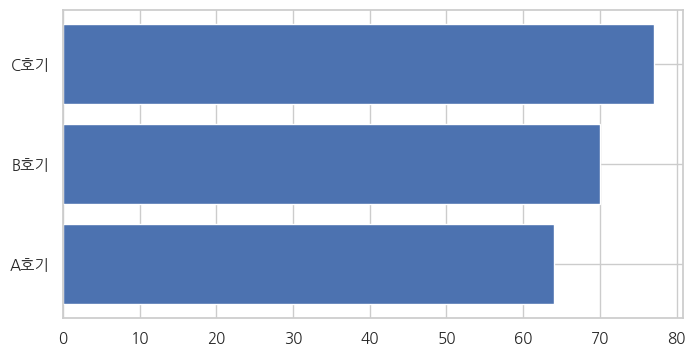

In [44]:

plt.figure(figsize=(8, 4))
plt.barh(['A호기', 'B호기', 'C호기'], [64, 70, 77])
plt.show()

# 실습 1. 막대 그래프 직접 그리기
설비별 평균 온도를 막대로, 색·가로 막대로 변형

목표
- 범주별 값을 막대로 비교하고 색·방향을 바꿔 강조

단계
- groupby로 설비별 평균 온도를 구해 막대로 그리기
- 색 리스트로 가장 뜨거운 설비만 강조하고 너비 조절
- barh로 가로 막대로 바꾸고 제목·축 이름 붙이기

예상 결과
- 설비별 평균 온도 막대(C호기 최고), 색·가로 변형

배치
로트A    858.420000
로트B    859.813333
로트C    860.421429
Name: 온도, dtype: float64


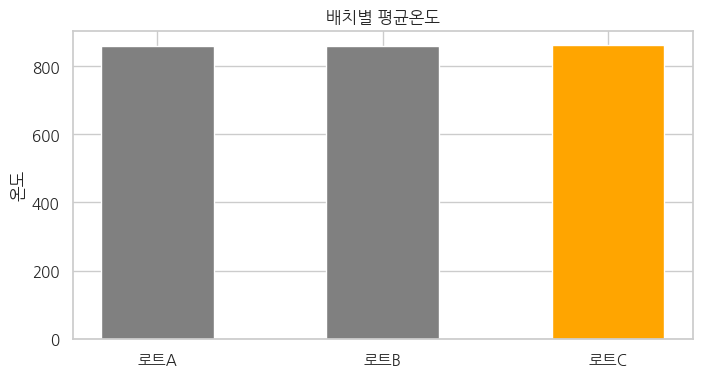

In [59]:
df = pd.read_csv('17_열처리.csv')

avg = df.groupby('배치')['온도'].mean()
print(avg.head()) # 값을 확인해서 잘 계산되었는지부터 봅시다!

plt.figure(figsize=(8, 4))

# avg라는 Pandas의 Series 정보 중에
# index labele들을 x축에 자리잡게 하고
# 개별 시리즈 값들을 y축에 높이로 만든다
plt.bar(avg.index, avg.values, color=['gray', 'gray', 'orange'], width = 0.5)

plt.title('배치별 평균온도')
plt.ylabel('온도')
plt.show()

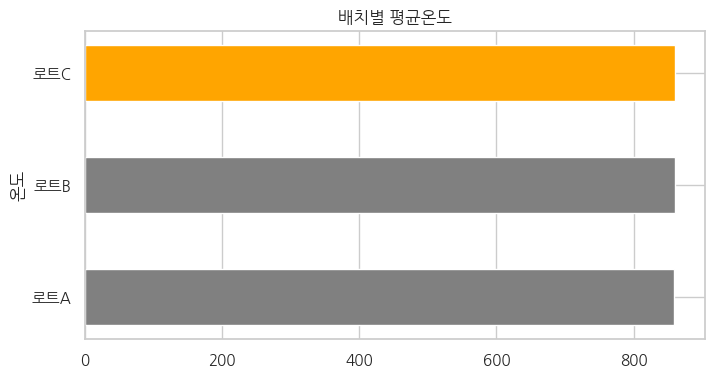

In [63]:
plt.figure(figsize=(8, 4))

plt.barh(avg.index, avg.values, color=['gray', 'gray', 'orange'], height = 0.5)

plt.title('배치별 평균온도')
plt.ylabel('온도')
plt.show()

## 실습 2. 범주별 집계 막대 그래프
- 개수·평균을 집계해 범주별로 막대 비교

목표
- value_counts·groupby로 집계한 값을 막대로 비교

단계
- 상태 열의 개수를 세어 막대로 그리기
- 구역으로 그룹을 나눠 평균 진동을 막대로 그리기
- 제목·축 이름을 붙여 완성

예상 결과
- 상태 정상 17·점검 4, 구역별 평균 진동 비교

상태
정상    42
승온     2
Name: count, dtype: int64


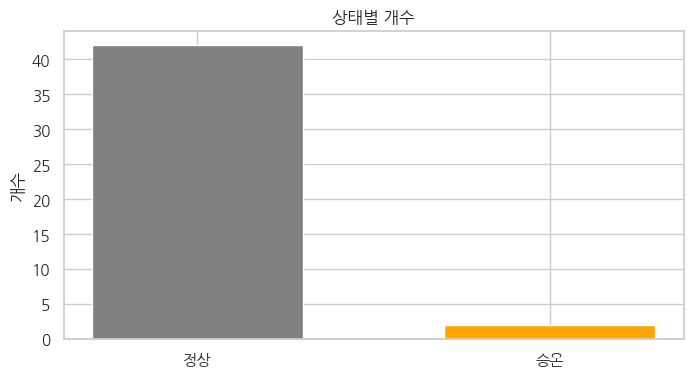

In [67]:
status = df['상태'].value_counts()
print(status.head())

plt.figure(figsize=(8, 4))
plt.bar(status.index, status.values, color=['gray', 'orange'], width=0.6)
plt.title('상태별 개수')
plt.ylabel('개수')
plt.show()


배치
로트A    81.906667
로트B    75.840000
로트C    69.621429
Name: OP값, dtype: float64


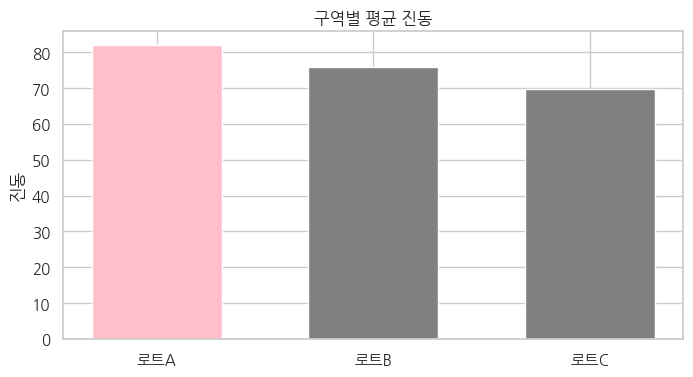

In [70]:
sections = df.groupby('배치')['OP값'].mean()
print(sections.head())

plt.figure(figsize=(8, 4))
plt.bar(sections.index, sections.values, color=['pink', 'gray', 'gray'], width=0.6)
plt.title('구역별 평균 진동')
plt.ylabel('진동')
plt.show()

## 실습 3. 히스토그램 직접 그리기
- 온도 분포를 히스토그램으로, bins로 구간 조절

목표
- 숫자 분포를 히스토그램으로 그리고 bins로 구간 조절

단계
- 온도 열을 hist로 그려 자동 구간 분포 확인
- bins를 작게·크게 바꿔 구간 수에 따른 모양 비교
- 제목·축 이름을 붙여 완성

예상 결과
- 온도 구간별 개수 분포, bins 5·20의 모양 차이

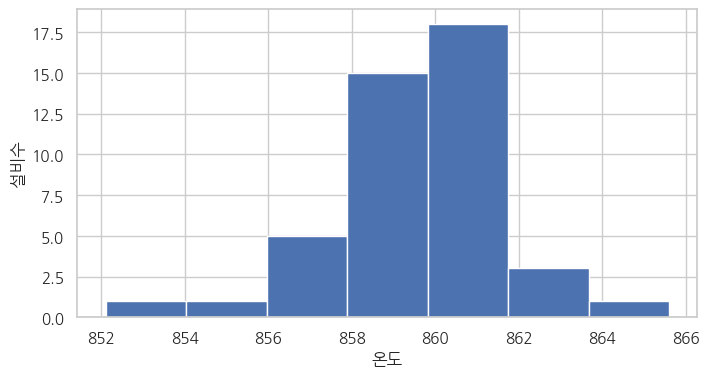

In [83]:
# 간단한 히스토그램 만들기
plt.figure(figsize=(8, 4))
plt.hist(df['온도'], bins=7)
plt.xlabel('온도')
plt.ylabel('설비수')
plt.show()

## 실습 4. 센서값 분포 히스토그램
분포를 그리고 평균·표준편차·이상 설비로 해석

목표
- 분포를 그리고 평균·표준편차와 이상 설비로 해석

단계
- 온도 분포를 히스토그램으로 그리기
- 평균과 표준편차를 구해 분포의 중심·퍼짐과 비교
- 조건 필터링으로 정상 범위를 벗어난 설비 수 확인

예상 결과
- 온도 평균 70.0·표준편차 5.6, 78 이상 설비 2대

859.5318181818183
2.1051180961484066
2


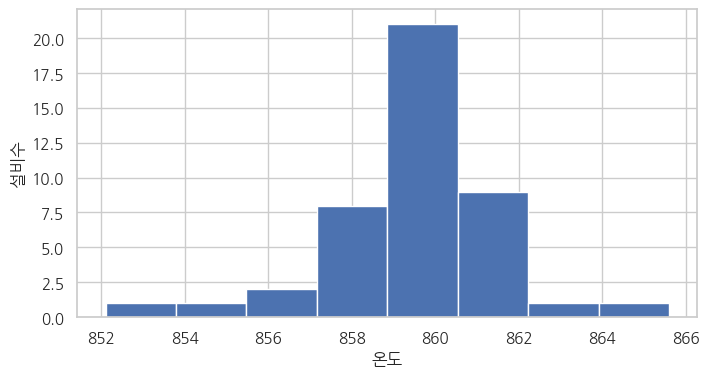

In [88]:
# 평균 온도와 분산
print(df['온도'].mean()) # 859.5318181818183
print(df['온도'].std()) # 2.1051180961484066
# 862 이상의 높은 온도 갯수
high = df[df['온도'] >= 862]
print(len(high)) # 2

# 간단한 히스토그램 만들기
plt.figure(figsize=(8, 4))
plt.hist(df['온도'], bins=8)
plt.xlabel('온도')
plt.ylabel('설비수')
plt.show()

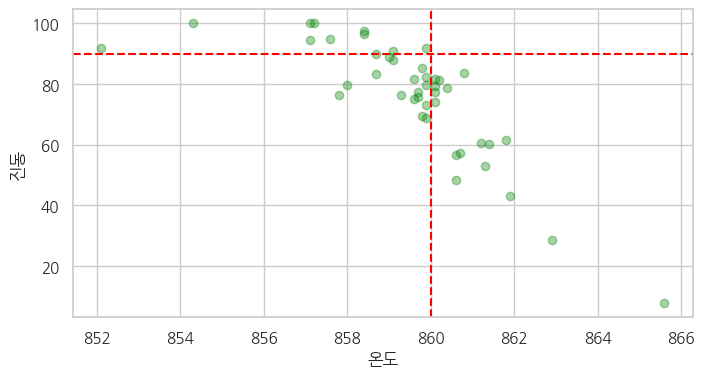

In [99]:
# 간단한 산점도 그래프

plt.figure(figsize=(8, 4))
plt.scatter(df['온도'], df['OP값'], color='green', alpha=0.35)
plt.axhline(y=90.0, color='red', linestyle="--") # 기준선
plt.axvline(x=860.0, color='red', linestyle="--")
plt.xlabel('온도')
plt.ylabel('진동')
plt.show()

## 실습 5. 산점도로 센서 간 관계 분석
온도-진동 산점도에 상태별 색·기준선 추가

목표
- 두 변수 산점도에 상태별 색과 임계 기준선 추가

단계
- 온도와 진동을 산점도로 찍어 관계 확인
- 상태를 색으로 매핑해 점검·정상을 색으로 구분
- axhline으로 진동 임계 기준선 그리기

예상 결과
- 온도↑ 진동↑ 양의 관계, 상태별 색·기준선 표시

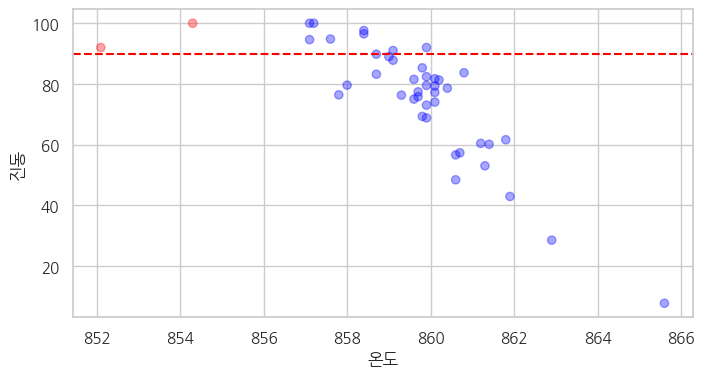

In [103]:
# 간단한 산점도 그래프

plt.figure(figsize=(8, 4))

colors = df['상태'].map({'정상': 'blue', '승온': 'red'})
plt.scatter(df['온도'], df['OP값'], color=colors, alpha=0.35)

plt.axhline(y=90.0, color='red', linestyle="--") # 기준선
plt.xlabel('온도')
plt.ylabel('진동')
plt.show()

## 실습 6
앞서 온도와 OP값(소음) 산포도를 참고해 온도와 CP값(진동) 산포도도 만들고 관계를 분석 판단해보세요.

## 실습7
17_열처리_공정.csv

1. 전체 shape 확인
2. 결측이 얼마 있는지 확인
3. 결측을 평균값으로 매꾸기

In [107]:
df_wide = pd.read_csv('17_열처리_공정.csv')
print(df_wide.shape)
print(df_wide.isna().sum().sum())
df_wide2 = df_wide.fillna(df_wide.mean(numeric_only=True))
print(df_wide2.isna().sum().sum())

(120, 8)
25
0


## 실습8. 시각화 리포트 완성과 저장


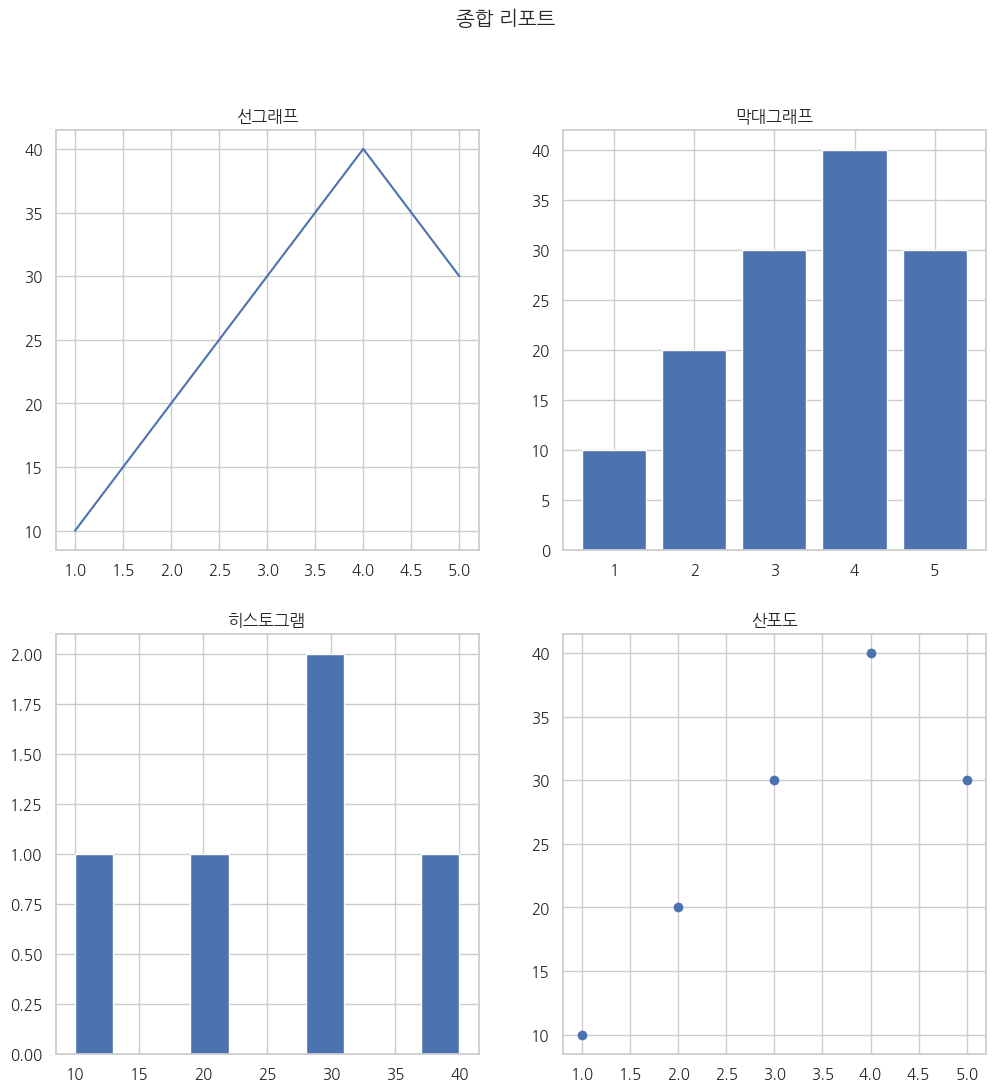

In [114]:
# 2x2 종합 그래프 만들기

plt.figure(figsize=(12, 12))
plt.suptitle('종합 리포트')

plt.subplot(2, 2, 1) # 가로2, 세로2인 종합그래프판의 1번영역을 사용할거임
plt.plot([1, 2, 3, 4, 5], [10, 20, 30, 40, 30])
plt.title('선그래프')

plt.subplot(2, 2, 2)
plt.bar([1, 2, 3, 4, 5], [10, 20, 30, 40, 30])
plt.title('막대그래프')

plt.subplot(2, 2, 3)
plt.hist([10, 20, 30, 40, 30])
plt.title('히스토그램')

plt.subplot(2, 2, 4)
plt.scatter([1, 2, 3, 4, 5], [10, 20, 30, 40, 30])
plt.title('산포도')

plt.show()

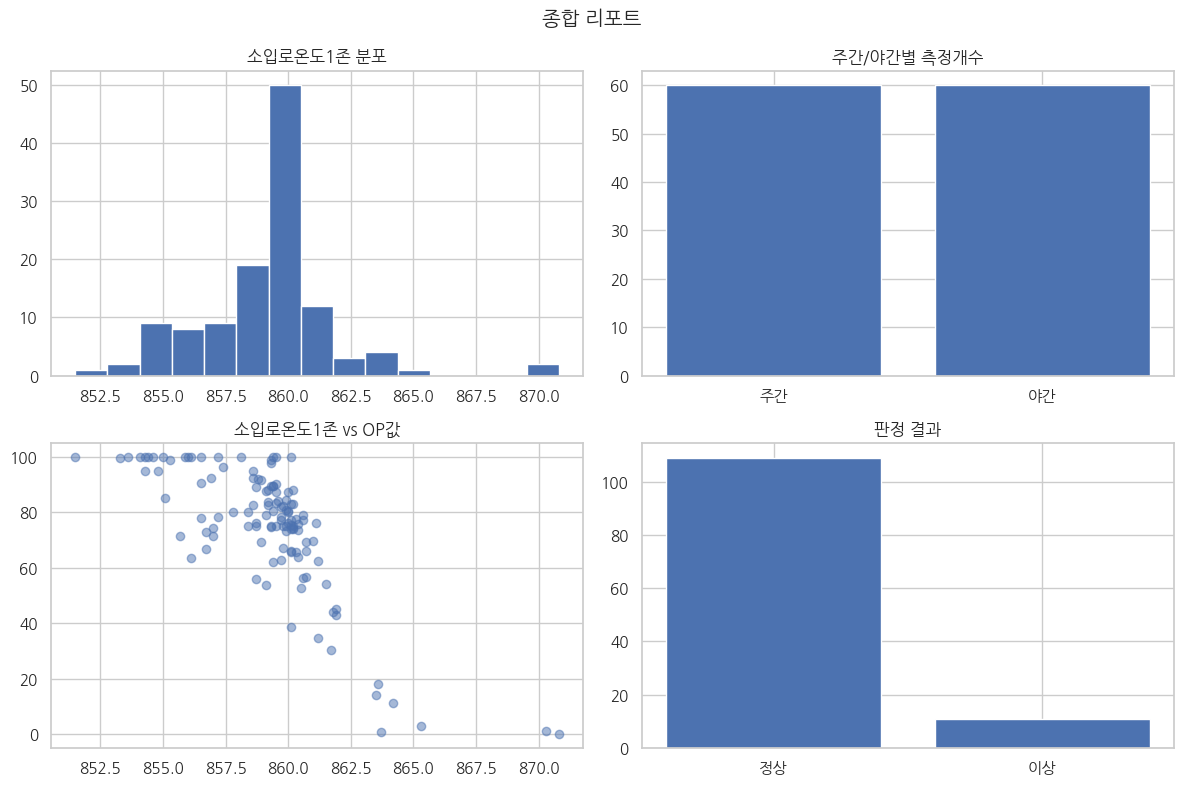

In [124]:
# 2x2 종합 그래프 만들기

plt.figure(figsize=(12, 8))
plt.suptitle('종합 리포트')

plt.subplot(2, 2, 1) # 가로2, 세로2인 종합그래프판의 1번영역을 사용할거임
plt.hist(df_wide2['소입로온도1존'], bins=15);
plt.title('소입로온도1존 분포')

plt.subplot(2, 2, 2)
counts = df_wide2['라인'].value_counts()
plt.bar(counts.index, counts.values)
plt.title('주간/야간별 측정개수')

plt.subplot(2, 2, 3)
plt.scatter(df_wide2['소입로온도1존'], df_wide2['OP값'], alpha=0.5)
plt.title('소입로온도1존 vs OP값')

plt.subplot(2, 2, 4)
counts = df_wide2['result'].value_counts()
plt.bar(counts.index, counts.values)
plt.title('판정 결과')

plt.tight_layout() # 칸 겹침 제거, 습관적으로 show 앞에 적용
plt.show()